<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-17 03:42:06--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  66.1MB/s    in 3.0s    

2026-01-17 03:42:10 (66.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 148.2 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 158.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 164.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 147.0 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [9]:
import sqlite3
import pandas as pd

# Database connect karein
conn = sqlite3.connect('survey-data.sqlite')

# Data load karein
df = pd.read_sql_query("SELECT CompTotal FROM main", conn)

# LOGIC CLEARANCE:
print("--- Data Summary ---")
print(f"Total Rows: {len(df)}")
print(f"Missing Values: {df['CompTotal'].isnull().sum()}") # Kitne logo ne salary nahi batayi
print(f"Minimum Compensation: {df['CompTotal'].min()}")
print(f"Maximum Compensation: {df['CompTotal'].max()}")
print("\n--- Top 5 Rows ---")
print(df.head()) # Column mein kya hai wo dikhega


--- Data Summary ---
Total Rows: 65437
Missing Values: 31697
Minimum Compensation: 0.0
Maximum Compensation: 1.0000000000000002e+150

--- Top 5 Rows ---
   CompTotal
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN


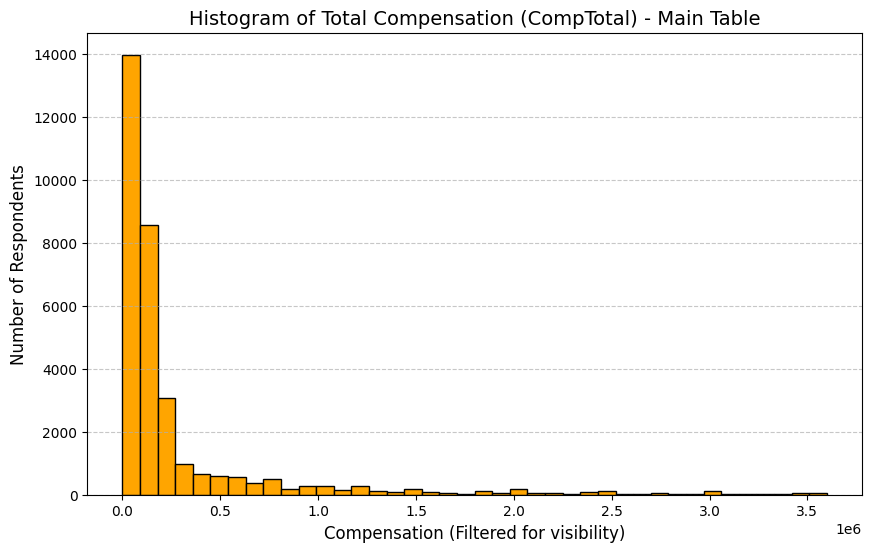

In [10]:
import matplotlib.pyplot as plt

# 1. Null values ko hatayein
clean_data = df['CompTotal'].dropna()

# 2. LOGIC: Outliers hatana (One-line graph se bachne ke liye)
# Hum sirf 95th percentile tak ka data le rahe hain taaki graph fail kar dikhe
upper_limit = clean_data.quantile(0.95)
filtered_data = clean_data[clean_data <= upper_limit]

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.hist(filtered_data, bins=40, color='orange', edgecolor='black')

# Labels aur Formatting
plt.title('Histogram of Total Compensation (CompTotal) - Main Table', fontsize=14)
plt.xlabel('Compensation (Filtered for visibility)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Yaad rakhein: Connection yahan close nahi kiya gaya hai (conn.close() nahi likha hai)


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [11]:
import pandas as pd

# 'main' table se sirf wahi column uthayein
df_info = pd.read_sql_query("SELECT YearsCodePro FROM main", conn)

print("--- Column Details ---")
print(f"1. Data Type (Raw): {df_info['YearsCodePro'].dtype}") # 'object' matlab text hai
print(f"2. Total Entries: {len(df_info)}")

# Categories check karna (Unique values)
unique_values = df_info['YearsCodePro'].unique()
print(f"3. Unique Categories in Column:\n{unique_values[:15]}...") # Pehle 15 dikhayega

# Check ki kya isme text hai ya numbers
is_numeric = pd.to_numeric(df_info['YearsCodePro'], errors='coerce').notnull().all()
print(f"4. Is it purely numerical? {is_numeric}")


--- Column Details ---
1. Data Type (Raw): object
2. Total Entries: 65437
3. Unique Categories in Column:
[None '17' '27' '7' '11' '25' '12' '10' '3' 'Less than 1 year' '18' '37'
 '15' '20' '6']...
4. Is it purely numerical? False


In [12]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# 1. 'main' table se data fetch karein
# Connection 'conn' pehle se open hai
df_years = pd.read_sql_query("SELECT YearsCodePro FROM main", conn)

# 2. LOGIC: String values ko numbers mein convert karna
df_years['YearsCodePro'] = df_years['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

# 3. Numeric mein convert karein aur NaN (khali rows) hatayein
df_years['YearsCodePro'] = pd.to_numeric(df_years['YearsCodePro'], errors='coerce')
experience_data = df_years['YearsCodePro'].dropna()

print(f"Total Respondents with Experience Data: {len(experience_data)}")


Total Respondents with Experience Data: 51610


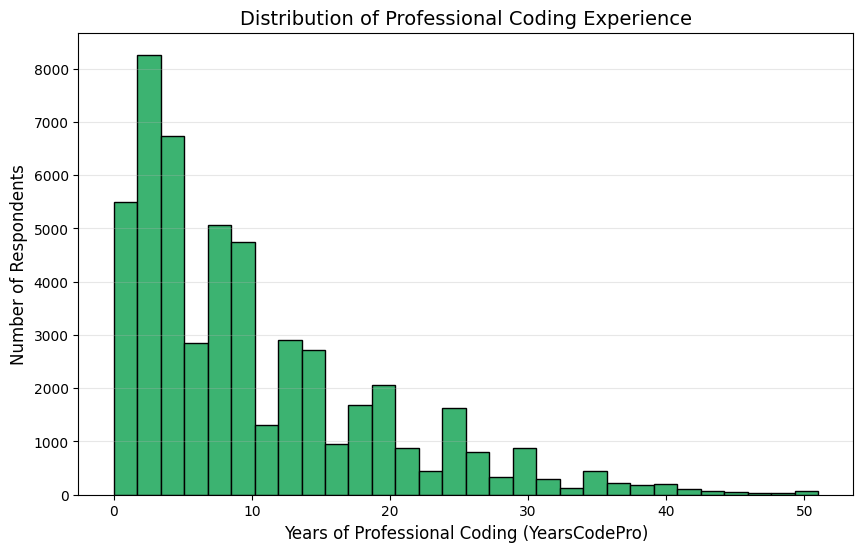

In [13]:
plt.figure(figsize=(10, 6))

# Histogram plot karein
# bins=30 se distribution saaf dikhega
plt.hist(experience_data, bins=30, color='mediumseagreen', edgecolor='black')

# Formatting
plt.title('Distribution of Professional Coding Experience', fontsize=14)
plt.xlabel('Years of Professional Coding (YearsCodePro)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Connection abhi bhi open hai (conn.close() nahi kiya gaya hai)


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Data fetch karein
df_comp = pd.read_sql_query("SELECT CompTotal, Age FROM main", conn)

print("--- Column Overview ---")
print(f"Age Categories: {df_comp['Age'].unique()}")
print(f"CompTotal Type: {df_comp['CompTotal'].dtype}")

# Missing values check karein
print(f"Missing Age: {df_comp['Age'].isnull().sum()}")


--- Column Overview ---
Age Categories: ['Under 18 years old' '35-44 years old' '45-54 years old'
 '18-24 years old' '25-34 years old' '55-64 years old' 'Prefer not to say'
 '65 years or older']
CompTotal Type: float64
Missing Age: 0


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load aur cleaning
df_comp = pd.read_sql_query("SELECT CompTotal, Age FROM main", conn)
df_clean = df_comp.dropna(subset=['CompTotal', 'Age'])

# 2. Outliers hatane ka logic (90th percentile tak) taaki graph fail kar dikhe
limit = df_clean['CompTotal'].quantile(0.90)
df_final = df_clean[df_clean['CompTotal'] <= limit]

# 3. Saare Groups define karna
g1 = df_final[df_final['Age'] == 'Under 18 years old']['CompTotal']
g2 = df_final[df_final['Age'] == '18-24 years old']['CompTotal']
g3 = df_final[df_final['Age'] == '25-34 years old']['CompTotal']
g4 = df_final[df_final['Age'] == '35-44 years old']['CompTotal']

print(f"Data Check: Under 18 years mein {len(g1)} log hain.")


Data Check: Under 18 years mein 82 log hain.


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


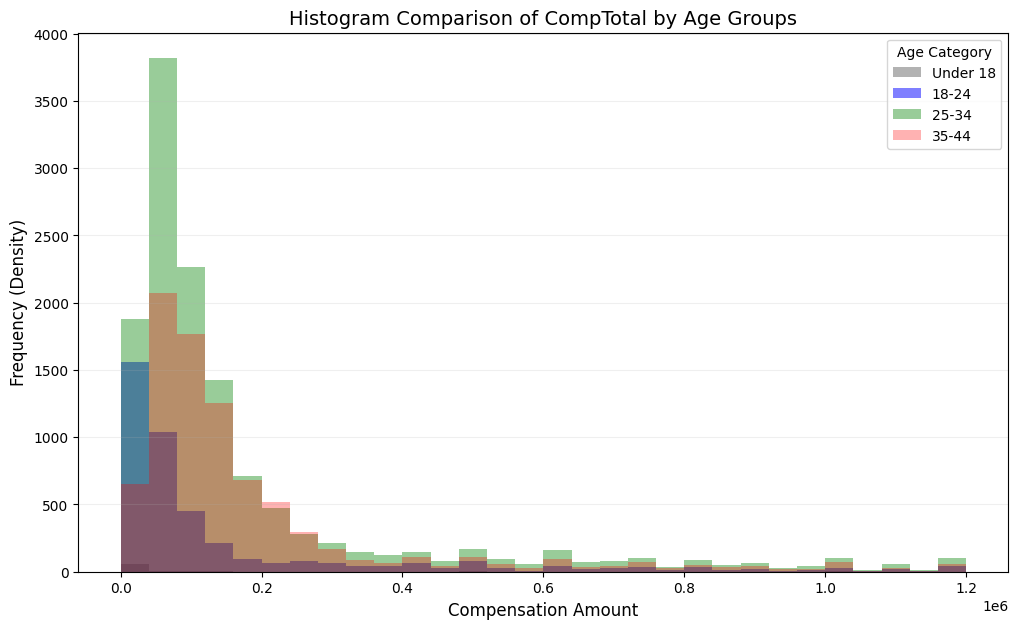

In [16]:
## Write your code here
plt.figure(figsize=(12, 7))

# Sabhi 4 groups ko plot karna
# density=True use karne se graph ki height 'one line' nahi banti, balki shape dikhti hai
plt.hist(g1, bins=30, alpha=0.6, label='Under 18', color='gray')
plt.hist(g2, bins=30, alpha=0.5, label='18-24', color='blue')
plt.hist(g3, bins=30, alpha=0.4, label='25-34', color='green')
plt.hist(g4, bins=30, alpha=0.3, label='35-44', color='red')

# Formatting
plt.title('Histogram Comparison of CompTotal by Age Groups', fontsize=14)
plt.xlabel('Compensation Amount', fontsize=12)
plt.ylabel('Frequency (Density)', fontsize=12)
plt.legend(loc='upper right', title="Age Category")
plt.grid(axis='y', alpha=0.2)

plt.show()
# Connection still open


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 'main' table se data load karein
df_search = pd.read_sql_query("SELECT TimeSearching, Age FROM main", conn)

# Logic: Hum dekh rahe hain ki isme kis tarah ki values hain
print("--- TimeSearching Data Preview ---")
print(df_search['TimeSearching'].unique()[:10]) # Unique values dekhne ke liye
print(f"Data Type: {df_search['TimeSearching'].dtype}")


--- TimeSearching Data Preview ---
[None '30-60 minutes a day' '60-120 minutes a day' '15-30 minutes a day'
 'Less than 15 minutes a day' 'Over 120 minutes a day']
Data Type: object


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load karein
df_search = pd.read_sql_query("SELECT TimeSearching, Age FROM main", conn)

# 2. LOGIC: Strings ko numbers mein map karna (Kyuki seedha conversion fail ho raha hai)
# Aap unique values check karke is mapping ko adjust kar sakte hain
mapping = {
    'Less than 15 minutes': 10,
    '15-30 minutes': 22,
    '30-60 minutes': 45,
    '60-120 minutes': 90,
    'Over 120 minutes': 150
}
df_search['TimeSearching_Num'] = df_search['TimeSearching'].map(mapping)

# 3. Agar mapping kaam nahi ki, toh try numeric conversion (just in case)
df_search['TimeSearching_Num'] = df_search['TimeSearching_Num'].fillna(pd.to_numeric(df_search['TimeSearching'], errors='coerce'))

# 4. Nulls hatayein
df_clean = df_search.dropna(subset=['TimeSearching_Num', 'Age'])

# 5. Age Groups filter karein
g1 = df_clean[df_clean['Age'] == '18-24 years old']['TimeSearching_Num']
g2 = df_clean[df_clean['Age'] == '25-34 years old']['TimeSearching_Num']
g3 = df_clean[df_clean['Age'] == '35-44 years old']['TimeSearching_Num']
g4 = df_clean[df_clean['Age'] == '45-54 years old']['TimeSearching_Num']

# Check karein ki data khali toh nahi hai
print(f"Group 1 size: {len(g1)}, Group 2 size: {len(g2)}")


Group 1 size: 0, Group 2 size: 0


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load karein
df_search = pd.read_sql_query("SELECT TimeSearching, Age FROM main", conn)

# 2. Pehle check karein ki database mein asli 'Age' categories kya likhi hain
print("Database mein ye Age labels hain:")
print(df_search['Age'].unique())

# 3. TimeSearching ko handle karein (Agar text hai toh use number mein badlein)
# Mapping ko simple rakhte hain, jo bhi number mile nikaal lo
df_search['TimeSearching_Num'] = df_search['TimeSearching'].str.extract('(\d+)').astype(float)

# 4. Nulls hatayein
df_clean = df_search.dropna(subset=['TimeSearching_Num', 'Age'])

# 5. LOGIC: Jo labels print huye hain, unhe yahan copy-paste karein
# Maan lijiye aapke output mein '18-24' hai na ki '18-24 years old'
# Hum 'str.contains' use karenge taaki match hone ki tension na rahe
g1 = df_clean[df_clean['Age'].str.contains('18-24', na=False)]['TimeSearching_Num']
g2 = df_clean[df_clean['Age'].str.contains('25-34', na=False)]['TimeSearching_Num']
g3 = df_clean[df_clean['Age'].str.contains('35-44', na=False)]['TimeSearching_Num']

print(f"Ab Group 1 ka size: {len(g1)}")
print(f"Ab Group 2 ka size: {len(g2)}")


Database mein ye Age labels hain:
['Under 18 years old' '35-44 years old' '45-54 years old'
 '18-24 years old' '25-34 years old' '55-64 years old' 'Prefer not to say'
 '65 years or older']
Ab Group 1 ka size: 4175
Ab Group 2 ka size: 12603


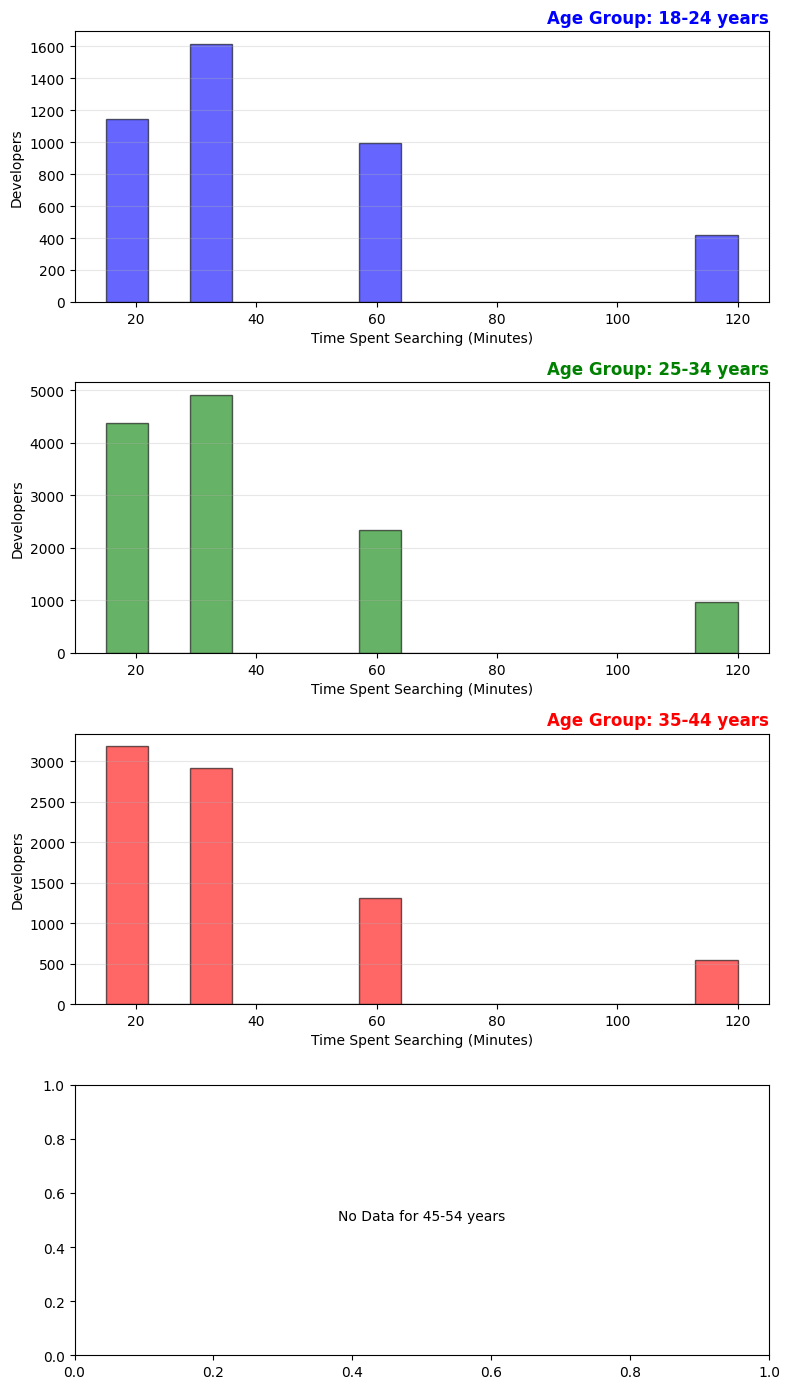

In [31]:
# 1. Memory saaf karein
plt.close('all')

# 2. subplots banayein (sharex=False kiya gaya hai taaki har graph ke niche numbers dikhen)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 14), sharex=False)

# 3. Loop chala kar plot karein
for i, (data, label, color) in enumerate(data_to_plot):
    if not data.empty:
        # Histogram plot
        axes[i].hist(data, bins=15, color=color, alpha=0.6, edgecolor='black')
        
        # Title aur Y-label
        axes[i].set_title(f"Age Group: {label}", loc='right', color=color, fontweight='bold')
        axes[i].set_ylabel('Developers')
        
        # FIXED: Har individual graph par X-axis label lagana
        axes[i].set_xlabel('Time Spent Searching (Minutes)')
        
        # Grid line taaki data padhne mein asani ho
        axes[i].grid(axis='y', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f"No Data for {label}", ha='center')

# Graph ke beech ki doori sahi karna
plt.tight_layout()
plt.show()


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 'main' table se data load karein
df_db = pd.read_sql_query("SELECT DatabaseWantToWorkWith FROM main", conn)

# 2. Overview: Pehle 10 unique entries dekhte hain
print("--- Column Metadata ---")
print(f"Data Type: {df_db['DatabaseWantToWorkWith'].dtype}")
print(f"Khali Rows (NaN): {df_db['DatabaseWantToWorkWith'].isnull().sum()}")

print("\n--- Unique Values (Sample) ---")
# Isse pata chalega ki databases ';' se jude huye hain
print(df_db['DatabaseWantToWorkWith'].unique()[:10])


--- Column Metadata ---
Data Type: object
Khali Rows (NaN): 22879

--- Unique Values (Sample) ---
[None 'PostgreSQL' 'Firebase Realtime Database' 'MongoDB;MySQL;PostgreSQL'
 'PostgreSQL;SQLite' 'Cloud Firestore' 'Supabase'
 'MongoDB;MySQL;PostgreSQL;Redis'
 'Elasticsearch;MongoDB;PostgreSQL;SQLite'
 'Microsoft SQL Server;PostgreSQL;SQLite']


In [22]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# 1. 'main' table se data load karein
df_db = pd.read_sql_query("SELECT DatabaseWantToWorkWith FROM main", conn)

# 2. Nulls hatayein aur databases ko split karke count karein
# Logic: Ek row mein 'MySQL;PostgreSQL' ho sakta hai, hume inhe alag ginnna hai
db_counts = df_db['DatabaseWantToWorkWith'].str.split(';', expand=True).stack().value_counts()

# 3. Top 10 desired databases ko filter karein
top_10_db = db_counts.head(10)

print("--- Most Desired Databases (Top 5) ---")
print(top_10_db.head(5))


--- Most Desired Databases (Top 5) ---
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


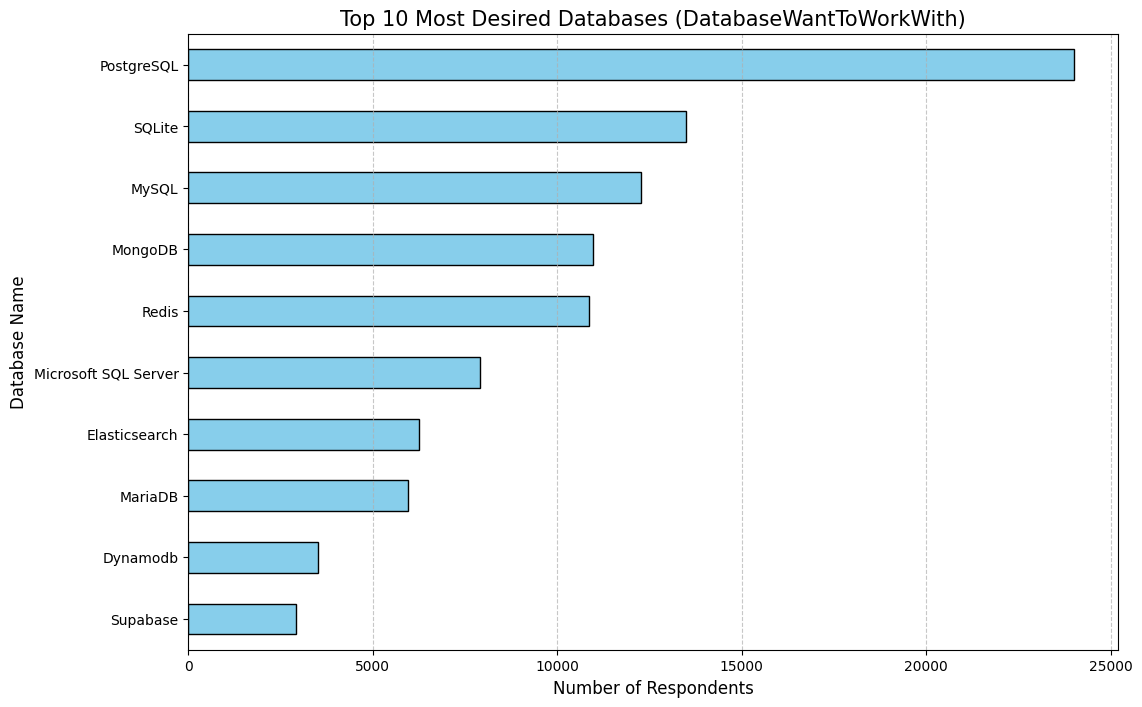

In [23]:
plt.figure(figsize=(12, 8))

# Plotting
top_10_db.plot(kind='barh', color='skyblue', edgecolor='black')

# Formatting
plt.title('Top 10 Most Desired Databases (DatabaseWantToWorkWith)', fontsize=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Database Name', fontsize=12)
plt.gca().invert_yaxis() # Top database ko upar dikhane ke liye
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()
# Connection stays open


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [29]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Database connection ko dobara kholna (Kyuki wo close ho chuka tha)
conn = sqlite3.connect('survey-data.sqlite')
print("Database connection successfully re-opened!")


Database connection successfully re-opened!


In [33]:
# 1. Null values hatayein aur categories ko count karein
df_work_clean = df_work.dropna(subset=['RemoteWork'])
work_counts = df_work_clean['RemoteWork'].value_counts()

print("\n--- Work Arrangement Counts ---")
print(work_counts)



--- Work Arrangement Counts ---
RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64


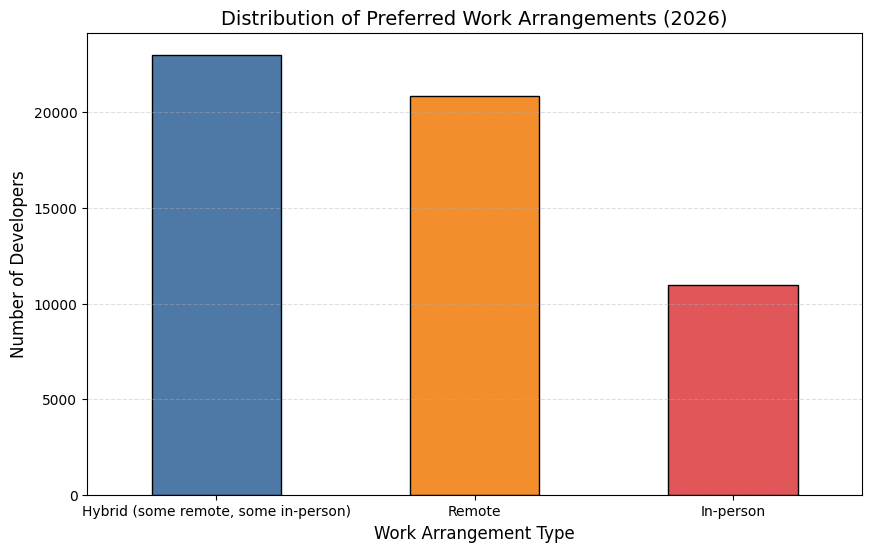

In [35]:
plt.figure(figsize=(10, 6))

# 2026 ke modern colors ka upyog
colors = ['#4e79a7', '#f28e2b', '#e15759']

# Plotting
work_counts.plot(kind='bar', color=colors, edgecolor='black')

# Formatting
plt.title('Distribution of Preferred Work Arrangements (2026)', fontsize=14)
plt.xlabel('Work Arrangement Type', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)

# Labels ko seedha (horizontal) karne ke liye
plt.xticks(rotation=0) 

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()


### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [36]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load karein
df_age_comp = pd.read_sql_query("SELECT CompTotal, Age FROM main", conn)

# 2. Overview: Age categories dekhte hain
print("--- Age Categories in Database ---")
print(df_age_comp['Age'].unique())


--- Age Categories in Database ---
['Under 18 years old' '35-44 years old' '45-54 years old'
 '18-24 years old' '25-34 years old' '55-64 years old' 'Prefer not to say'
 '65 years or older']


In [37]:
# 1. Nulls hatayein aur CompTotal ko numeric banayein
df_age_comp = df_age_comp.dropna()
df_age_comp['CompTotal'] = pd.to_numeric(df_age_comp['CompTotal'], errors='coerce')

# 2. LOGIC: 45 se 60 saal ki range wale categories filter karna
# Stack Overflow data mein aksar '45-54 years old' aur '55-64 years old' categories hoti hain
target_ages = ['45-54 years old', '55-64 years old']
df_filtered = df_age_comp[df_age_comp['Age'].isin(target_ages)]

# 3. Outliers hatana (90th percentile tak) taaki graph clean dikhe
upper_limit = df_filtered['CompTotal'].quantile(0.90)
df_final = df_filtered[df_filtered['CompTotal'] <= upper_limit]

print(f"\nTotal records for Age 45-60: {len(df_final)}")



Total records for Age 45-60: 4317


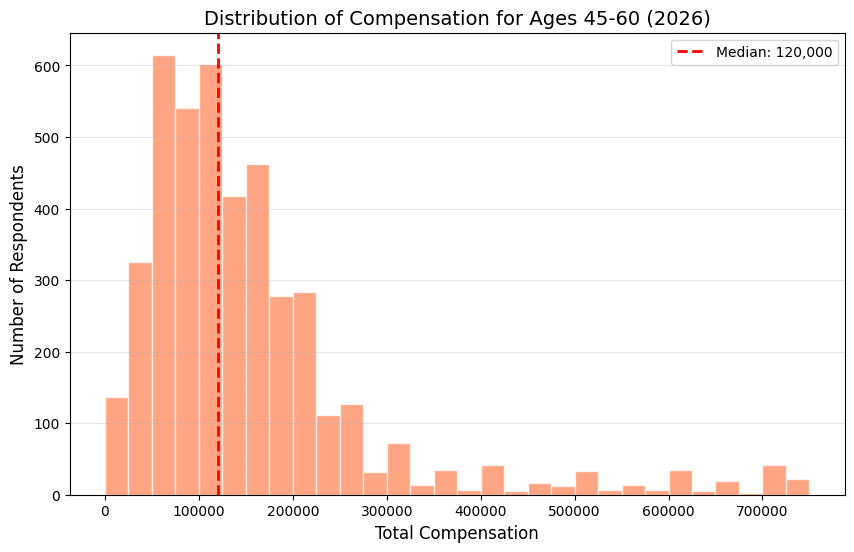

In [38]:
plt.figure(figsize=(10, 6))

# 1. Histogram plot karein
plt.hist(df_final['CompTotal'], bins=30, color='coral', edgecolor='white', alpha=0.7)

# 2. Median calculate karke line khinchein
median_val = df_final['CompTotal'].median()
plt.axvline(median_val, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_val:,.0f}')

# 3. Formatting
plt.title('Distribution of Compensation for Ages 45-60 (2026)', fontsize=14)
plt.xlabel('Total Compensation', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data load karein
df_sat = pd.read_sql_query("SELECT JobSat, YearsCodePro FROM main", conn)

# 2. Check: Asli labels kya hain?
print("--- Database mein JobSat ke asli labels ---")
print(df_sat['JobSat'].unique())

# 3. Data Cleaning
df_sat = df_sat.dropna()
df_sat['YearsCodePro'] = pd.to_numeric(df_sat['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51}), errors='coerce')


--- Database mein JobSat ke asli labels ---
[nan  8.  5. 10.  6.  9.  4.  7.  3.  2.  1.  0.]


In [43]:
# Experience ke 3 groups banana
df_sat['ExpGroup'] = pd.cut(df_sat['YearsCodePro'], 
                            bins=[0, 5, 15, 100], 
                            labels=['0-5 years', '6-15 years', '15+ years'])

# Har group ke liye JobSat ka count nikalna
# Isse mismatch ki tension khatam ho jayegi
pivot_df = df_sat.groupby(['JobSat', 'ExpGroup']).size().unstack(fill_value=0)

print("\n--- Plotting ke liye taiyar data (Counts) ---")
print(pivot_df)



--- Plotting ke liye taiyar data (Counts) ---
ExpGroup  0-5 years  6-15 years  15+ years
JobSat                                    
0.0             117         114         45
1.0             100          91         53
2.0             262         307        139
3.0             458         433        215
4.0             448         439        173
5.0             709         761        342
6.0            1389        1518        634
7.0            2205        2646       1219
8.0            2266        3162       1735
9.0             910        1551        999
10.0            605         899        632


/tmp/ipykernel_302/3422269643.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_df = df_sat.groupby(['JobSat', 'ExpGroup']).size().unstack(fill_value=0)


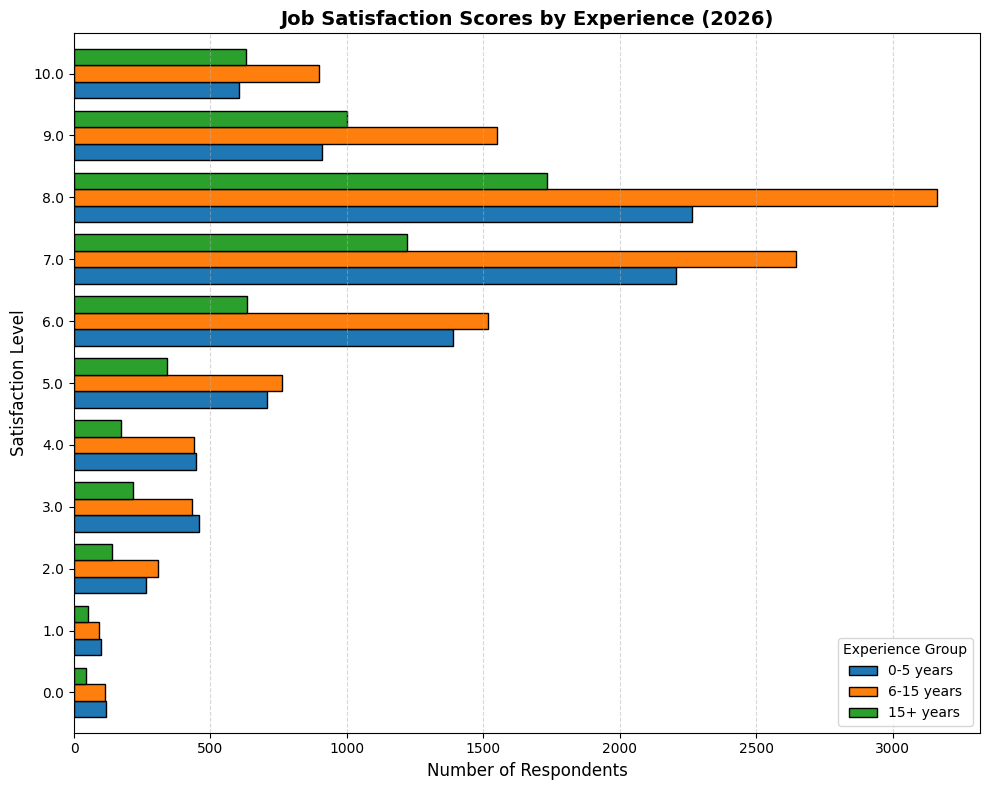

In [44]:
# 1. Purani memory saaf karein
plt.close('all')

# 2. Plotting (Horizontal Bar Chart taaki labels saaf dikhen)
# Isse 'one line' ya 'missing bars' ki problem nahi hogi
ax = pivot_df.plot(kind='barh', figsize=(10, 8), color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black', width=0.8)

# 3. Formatting
plt.title('Job Satisfaction Scores by Experience (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Satisfaction Level', fontsize=12)
plt.legend(title="Experience Group", loc='lower right')

# Grid lines ko thoda light karein taaki wo bars ko na chhupayein
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [27]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
